# EccoPy-3D Workflow

EccoPy-3D classifies a **full 3-D reflectivity volume** (Z x Y x X) into
echo type, using the same 2-D radial texture engine as EccoPy-2D-H at
every level, plus 3-D dual-threshold clumping (a port of LROSE's
ConvStratFinder/StormClump) and optional height/temp-based
sub-classification into 9 codes.

This is the most heavily validated EccoPy module (5 runs across 3 real
LROSE-ECCO cases, 99.8-99.98% agreement) — see the package README for
details. This notebook uses synthetic data for a self-contained,
runs-anywhere workflow example.

Walks through:

1. Generating a synthetic volume
2. Basic vs. sub-classified (height/temp) runs
3. `WindowSpec`, `TextureParams`, `ClassificationParams` (3-D fields:
   volume/extent filters, dual-threshold clumping)
4. `VerticalParams` (3-D-only; NOT shared with EccoPy-2D-V)
5. Debugging with `return_intermediates=True` and `levels=[...]`
6. Statistics with `eccopy.stats`
7. Plotting with `plot_result()` and EccoPy's colormaps
8. Known unvalidated/open items to be aware of


In [1]:
import sys
from pathlib import Path

# Walk up from the notebook's location until we find the directory
# containing the `eccopy` package folder, then add it to sys.path.
here = Path.cwd()
for candidate in [here, *here.parents]:
    if (candidate / "eccopy").is_dir():
        sys.path.insert(0, str(candidate))
        break

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
np.set_printoptions(precision=3, suppress=True)


In [2]:
from eccopy import eccopy3d, stats
from eccopy.params import WindowSpec, TextureParams, ClassificationParams, VerticalParams
from eccopy.eccopy3d.plot import plot_result
from eccopy.core.colormaps import (
    basic_echo_type_cmap, basic_echo_type_norm, BASIC_ECHO_TYPE_LABELS,
    echo_type_cmap, echo_type_norm, ECHO_TYPE_LABELS,
    convectivity_cmap, convectivity_norm,
)

## 1. Generate a synthetic volume

A (Z, Y, X) = (12, 40, 50) volume: a stratiform layer decreasing with
height, plus one convective tower that grows and decays with height
(peaking mid-volume, like a real storm's core).


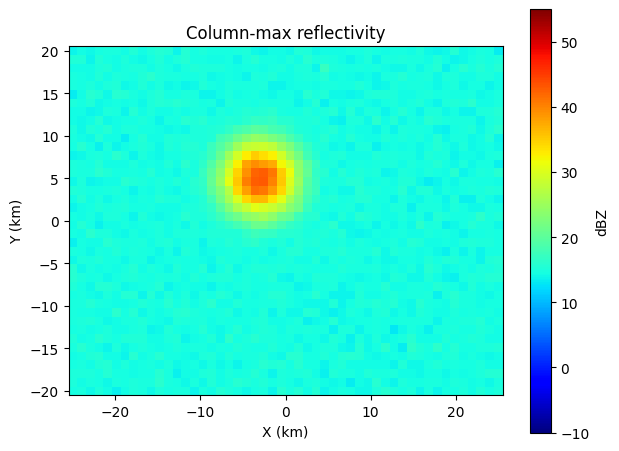

In [3]:
np.random.seed(4)
nz, ny, nx = 12, 40, 50
z_km = np.linspace(0.5, 11.5, nz)
y_km = np.linspace(-20, 20, ny)
x_km = np.linspace(-25, 25, nx)

dbz = 15 - 0.9 * z_km[:, None, None] + np.random.normal(0, 0.6, (nz, ny, nx))
yy, xx = np.meshgrid(y_km, x_km, indexing="ij")
for iz in range(nz):
    weight = np.exp(-((iz - 4) ** 2) / 8)   # tower peaks around z-index 4 (~4-5 km)
    tower = 32 * weight * np.exp(-((yy - 5) ** 2 + (xx + 3) ** 2) / 25)
    dbz[iz] += tower
dbz = np.clip(dbz, -20, 60)

col_max = np.nanmax(dbz, axis=0)
fig, ax = plt.subplots(figsize=(7, 5.5))
pc = ax.pcolormesh(x_km, y_km, col_max, cmap="jet", vmin=-10, vmax=55, shading="auto")
plt.colorbar(pc, ax=ax, label="dBZ")
ax.set(xlabel="X (km)", ylabel="Y (km)", title="Column-max reflectivity")
ax.set_aspect("equal")
plt.show()

## 2. Basic vs. sub-classified runs

Like EccoPy-2D-V, providing `height` (and `temp`, `topo`/`terrain_ht`)
enables sub-classification into 9 codes; omitting them gives the basic
3-code result.


In [4]:
window = WindowSpec((6, "km"))

r_basic = eccopy3d.run(dbz, coords_z=z_km, coords_y=y_km, coords_x=x_km, window=window)
print("Basic codes:", sorted(np.unique(r_basic.echo_type[~np.isnan(r_basic.echo_type)]).astype(int)))
print("n_clumps:", r_basic.n_clumps)

height_field = np.broadcast_to(z_km[:, None, None], (nz, ny, nx)).astype(float)
temp_field = 20 - 6.5 * height_field   # simple lapse-rate temperature field

r_sub = eccopy3d.run(dbz, coords_z=z_km, coords_y=y_km, coords_x=x_km, window=window,
                     height=height_field, temp=temp_field)
print("Sub-classified codes:", sorted(np.unique(r_sub.echo_type[~np.isnan(r_sub.echo_type)]).astype(int)))

Basic codes: [np.int64(0), np.int64(25), np.int64(32)]
n_clumps: 1
Sub-classified codes: [np.int64(0), np.int64(14), np.int64(16), np.int64(18), np.int64(25), np.int64(36)]


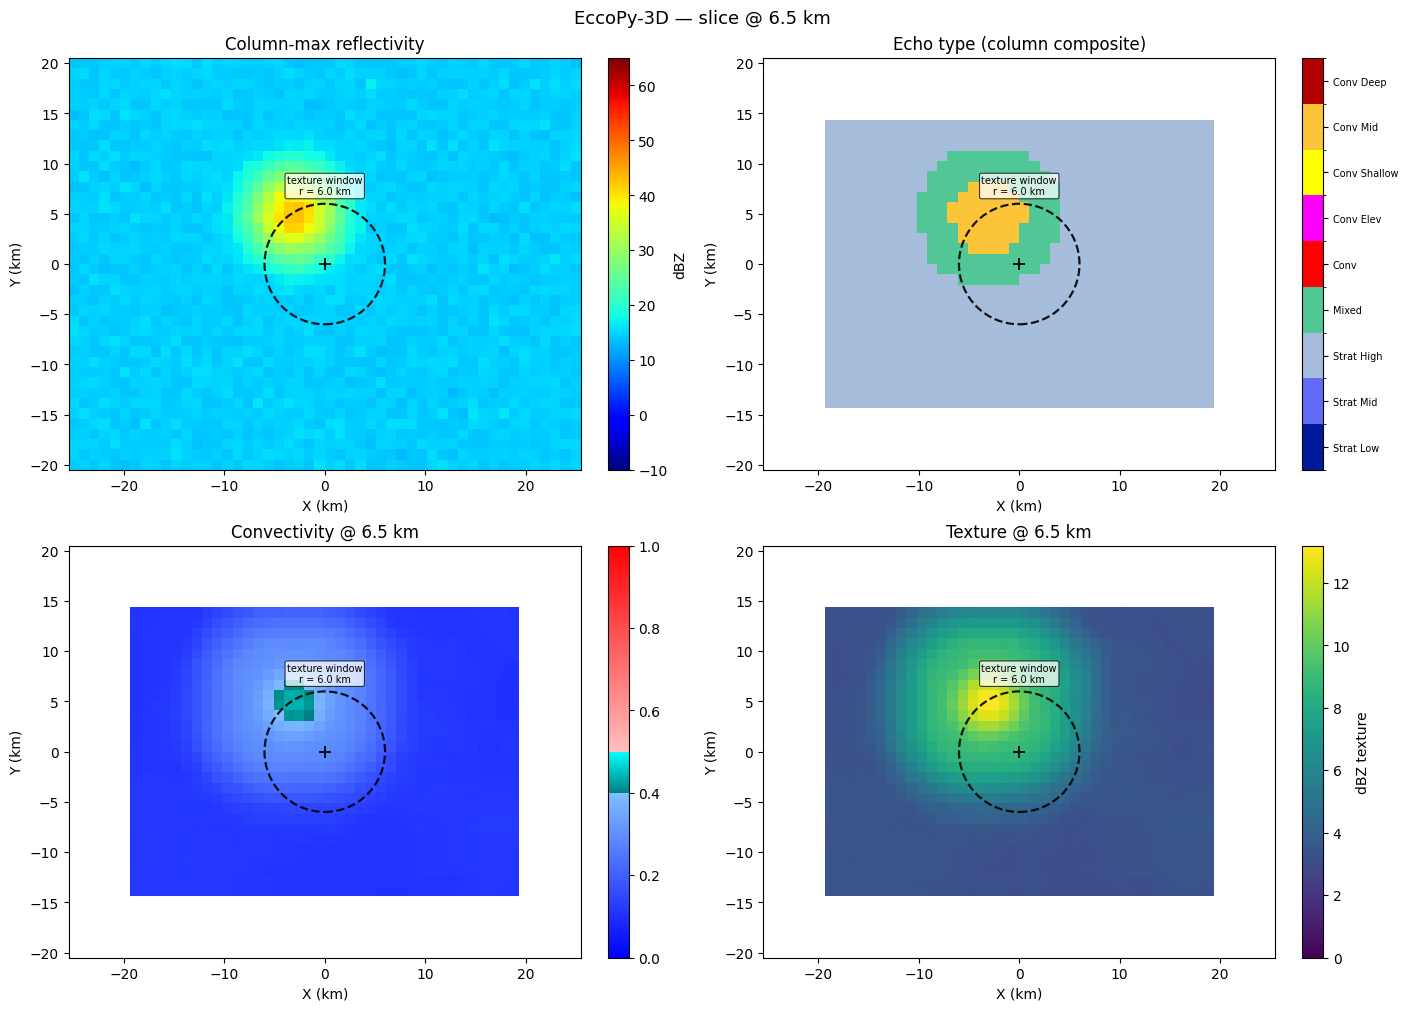

In [5]:
fig = plot_result(r_sub, dbz, coords_y=y_km, coords_x=x_km, coords_z=z_km)

## 3. `TextureParams` / `ClassificationParams` — 3-D-specific fields

Beyond the shared strat/mixed/conv thresholds, EccoPy-3D's
`ClassificationParams` adds volume/extent filters and dual-threshold
clumping controls:

| Field | Meaning | Default |
|---|---|---|
| `min_valid_volume_for_convective` | Minimum clump volume (km³) to remain Convective | 20.0 |
| `min_vert_extent_for_convective` | Minimum vertical extent (km) to remain Convective | 1.0 |
| `use_dual_thresholds` | Enable secondary-threshold sub-clump splitting | True |
| `secondary_convectivity` | Secondary convectivity threshold for splitting | 0.65 |
| `each_subclump_min_area_km2` | Minimum area (km²) for a sub-clump to survive splitting | 2.0 |
| `min_overlap_for_convective_clumps` | Overlap (pixels) required between stages | 1 (unvalidated above 1) |

`each_subclump_min_area_km2` is a **pseudo-volume** quirk in 3-D (not a
true area) — see the parameter's docstring; don't share a
`ClassificationParams` instance between EccoPy-2D-H and EccoPy-3D calls
without checking that field's meaning in each.


In [6]:
cp_strict_volume = ClassificationParams(min_valid_volume_for_convective=50.0)
r_strict = eccopy3d.run(dbz, coords_z=z_km, coords_y=y_km, coords_x=x_km, window=window,
                        class_params=cp_strict_volume)

print("Default volume filter (20 km^3) -- n_clumps:", r_basic.n_clumps,
      " conv%%: %.1f" % stats.convective_percentage(r_basic.echo_type))
print("Stricter filter (50 km^3)       -- n_clumps:", r_strict.n_clumps,
      " conv%%: %.1f" % stats.convective_percentage(r_strict.echo_type))

Default volume filter (20 km^3) -- n_clumps: 1  conv%: 0.4
Stricter filter (50 km^3)       -- n_clumps: 1  conv%: 0.4


## 4. `VerticalParams` — 3-D-only

`VerticalParams` controls the height/temperature thresholds used for 3-D
sub-classification (`vert_levels_type`, `shallow_threshold_*`,
`deep_threshold_*`). **This is scoped to the 3-D path only** —
EccoPy-2D-V's sub-classification hardcodes its own melt/temp thresholds
internally and ignores `VerticalParams` entirely (a coupling that was a
real, since-fixed bug — see that module's notebook / the package
README's validation history).


In [7]:
vp_default = VerticalParams()                                  # by_height, deep @ 9 km
vp_lower_deep = VerticalParams(deep_threshold_ht=6.0)           # call convection "deep" sooner

r_vp_default = eccopy3d.run(dbz, coords_z=z_km, coords_y=y_km, coords_x=x_km, window=window,
                            height=height_field, temp=temp_field, vert_params=vp_default)
r_vp_lower = eccopy3d.run(dbz, coords_z=z_km, coords_y=y_km, coords_x=x_km, window=window,
                          height=height_field, temp=temp_field, vert_params=vp_lower_deep)

def code_counts(echo):
    codes, counts = np.unique(echo[~np.isnan(echo) & (echo > 0)], return_counts=True)
    return dict(zip(codes.astype(int).tolist(), counts.tolist()))

print("deep_threshold_ht=9.0 (default):", code_counts(r_vp_default.echo_type))
print("deep_threshold_ht=6.0          :", code_counts(r_vp_lower.echo_type))

deep_threshold_ht=9.0 (default): {14: 5032, 16: 4170, 18: 3192, 25: 281, 36: 93}
deep_threshold_ht=6.0          : {14: 5032, 16: 990, 18: 6372, 25: 281, 36: 93}


## 5. Debugging with `return_intermediates=True` and `levels=[...]`

Like EccoPy-2D-H, EccoPy-3D's `fitted_dbz`/`detrended_dbz` come from the
slow per-point loop, applied per level. `levels` is **required** (a list
of Z-indices) — there is no "all levels" default, since that would
silently run the slow loop over the whole volume.


In [8]:
%%time
r_debug = eccopy3d.run(dbz, coords_z=z_km, coords_y=y_km, coords_x=x_km, window=window,
                       return_intermediates=True, levels=[3, 4, 5])
print("intermediate_levels:", r_debug.intermediate_levels)
print("fitted_dbz shape:", r_debug.fitted_dbz.shape)   # (len(levels), Y, X)

intermediate_levels: [3 4 5]
fitted_dbz shape: (3, 40, 50)
CPU times: user 1.96 s, sys: 4.5 ms, total: 1.97 s
Wall time: 1.98 s


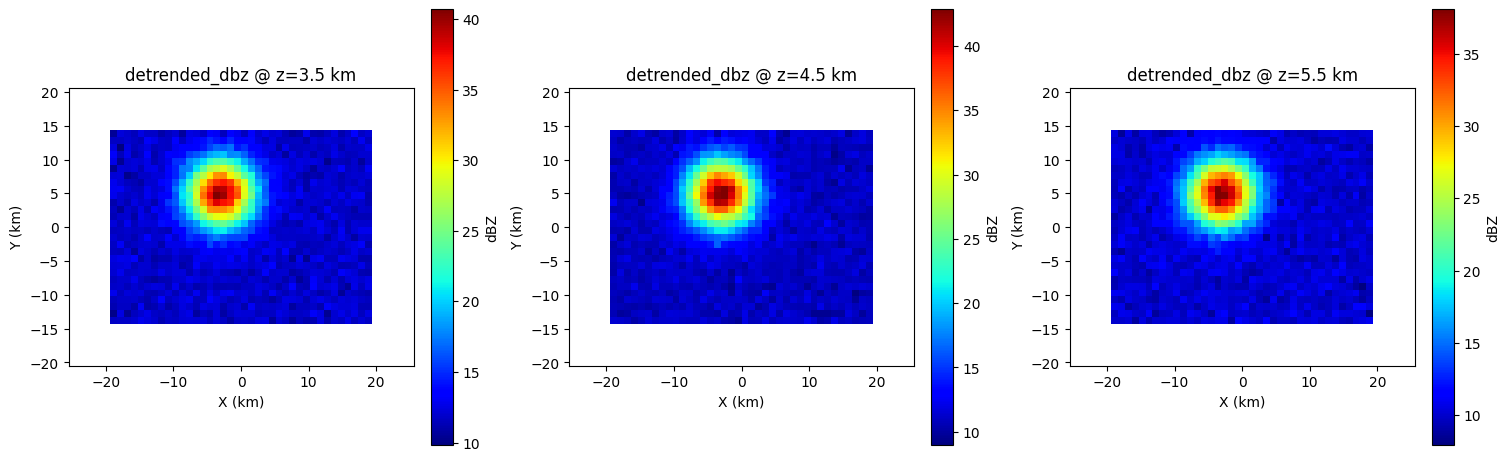

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
for ax, iz_local, iz_global in zip(axes, range(3), r_debug.intermediate_levels):
    pc = ax.pcolormesh(x_km, y_km, r_debug.detrended_dbz[iz_local], cmap="jet", shading="auto")
    plt.colorbar(pc, ax=ax, label="dBZ")
    ax.set(title=f"detrended_dbz @ z={z_km[iz_global]:.1f} km", xlabel="X (km)", ylabel="Y (km)")
    ax.set_aspect("equal")
plt.show()

## 6. Statistics with `eccopy.stats`

Full 3-D height/depth statistics work the same way as EccoPy-2D-V, plus
physical (km³) clump sizes via a 3-D `spacing` array.


n_valid: 24000
stratiform: 0.5164166666666666
mixed: 0.011708333333333333
convective: 0.003875
convective_pct: 0.3875
stratiform_pct: 51.641666666666666
mixed_pct: 1.1708333333333334
n_convective_clumps: 1
n_stratiform_clumps: 1
mean_convective_clump_size: 93.0
mean_convective_top_height: 5.0
mean_convective_base_height: 3.7857142857142856
mean_convective_depth: 1.2142857142857142
max_convective_top_height: 5.5


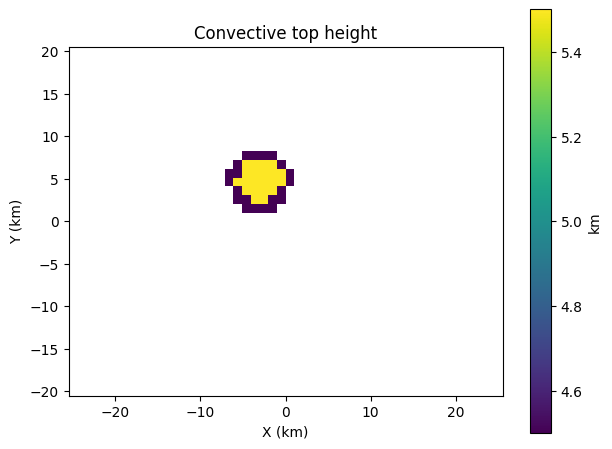

EccoPy-3D's own n_clumps (dual-threshold algorithm): 1
stats.n_clumps (relabeled from final echo_type):      1


In [10]:
summary = stats.summarize(r_sub.echo_type, height=height_field, axis=0)
for k, v in summary.items():
    if not isinstance(v, np.ndarray):
        print(f"{k}: {v}")

conv_top = stats.convective_top_height(r_sub.echo_type, height_field, axis=0)   # (Y, X)
fig, ax = plt.subplots(figsize=(7, 5.5))
pc = ax.pcolormesh(x_km, y_km, conv_top, cmap="viridis", shading="auto")
plt.colorbar(pc, ax=ax, label="km")
ax.set(title="Convective top height", xlabel="X (km)", ylabel="Y (km)")
ax.set_aspect("equal")
plt.show()

print("EccoPy-3D's own n_clumps (dual-threshold algorithm):", r_sub.n_clumps)
print("stats.n_clumps (relabeled from final echo_type):     ",
      stats.n_clumps(r_sub.echo_type, category="convective"))

## 7. Plotting

`plot_result()` (used above) gives the standard 4-panel view
(column-max reflectivity, column-composite echo type, and single-level
convectivity/texture slices). For custom figures, the same
`convectivity_cmap()`/`echo_type_cmap()`/`basic_echo_type_cmap()`
conventions apply as in the other notebooks.


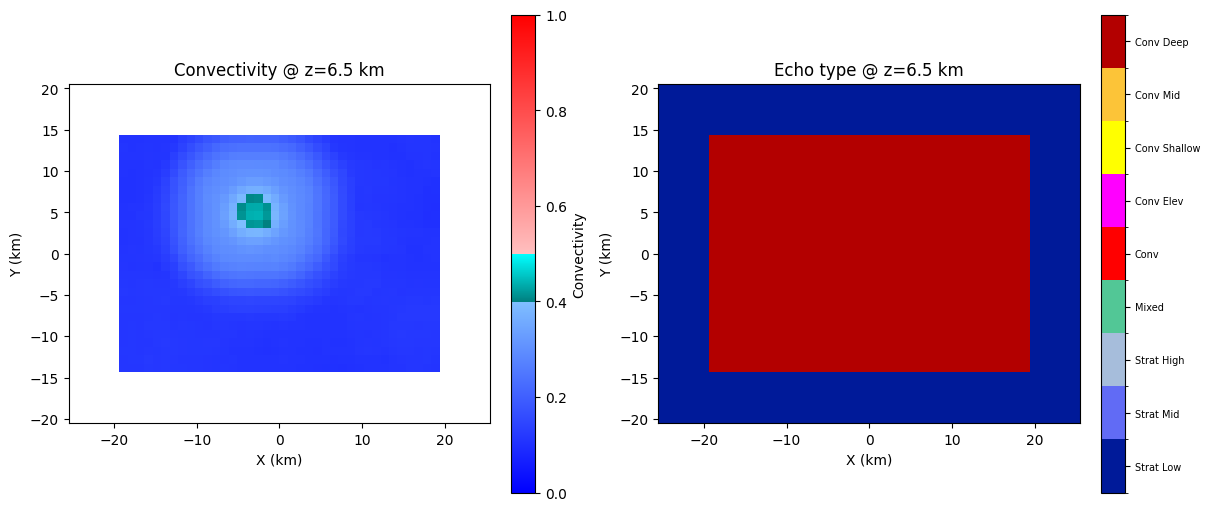

In [11]:
iz_mid = nz // 2
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

pc = axes[0].pcolormesh(x_km, y_km, r_sub.convectivity[iz_mid], cmap=convectivity_cmap(),
                        norm=convectivity_norm(), shading="auto")
plt.colorbar(pc, ax=axes[0], label="Convectivity")
axes[0].set(title=f"Convectivity @ z={z_km[iz_mid]:.1f} km", xlabel="X (km)", ylabel="Y (km)")
axes[0].set_aspect("equal")

pc = axes[1].pcolormesh(x_km, y_km, r_sub.echo_type[iz_mid], cmap=echo_type_cmap(),
                        norm=echo_type_norm(), shading="auto")
cb = plt.colorbar(pc, ax=axes[1], ticks=range(1, 10))
cb.ax.set_yticklabels(ECHO_TYPE_LABELS, fontsize=7)
axes[1].set(title=f"Echo type @ z={z_km[iz_mid]:.1f} km", xlabel="X (km)", ylabel="Y (km)")
axes[1].set_aspect("equal")
plt.show()

## 8. Known unvalidated / open items

EccoPy-3D is the most validated module, but a few configurations are
NOT yet validated against real reference output — see the package
README for the full, current list. As of this notebook:

- `min_overlap_for_convective_clumps > 1` — all real test cases used the
  TDRP default of 1.
- The `topo_km` AGL-subtraction path in clumping — unexercised by any
  real test case, and possibly not present in the real C++ path at all.
- `_grow_regions()`'s vectorized flood-fill order vs. the C++'s
  randomized order — negligible in practice, not bit-identical.

If your use case depends on any of these, treat results with
appropriate caution and consider validating against your own reference
output before relying on them.


## Summary

- EccoPy-3D combines EccoPy-2D-H's per-level 2-D radial texture with 3-D
  dual-threshold clumping and optional height/temp sub-classification.
- 3-D-specific `ClassificationParams` fields control volume/extent
  filters and dual-threshold clumping; `VerticalParams` (3-D only)
  controls sub-classification height/temp thresholds.
- `return_intermediates=True` requires an explicit `levels=[...]` list
  and uses the same slow per-point debug path as EccoPy-2D-H.
- `eccopy.stats` and the shared colormaps work identically to the other
  three modules.

This completes the four-module workflow tour — see the package README
for validation status per module and the full parameter reference.
